# LUOJIA-1-01 automatic LightGlue GCP workflow (batch of 100)

This notebook keeps the same **Web Mercator basemap + GDAL GCP warp** idea from your manual notebook, but replaces the manual point picking with **automatic LightGlue matching**.

What this notebook does:

1. sync only `LuoJia1-01*_meta.xml` metadata from `hf://buckets/cbernegger/LULO` to a local mirror
2. parse all available metadata and build a scene catalog
3. pick a **random, geographically non-overlapping** batch of **100** LUOJIA-1-01 scenes
4. download the selected `*_gec.tif` + `*_meta.xml` files
5. fetch a **Web Mercator** satellite basemap for each scene
6. run **SuperPoint + LightGlue** to find image correspondences automatically
7. reject bad matches with **RANSAC**
8. convert basemap pixels to `(lon, lat)`, sample `z` from the DEM VRT, and write GCPs
9. run the same style of **GDAL GCP warp** as in your working notebook
10. save successful warped scenes into a **separate output folder** for downstream processing

---

## Important limitation

Like your manual notebook, this is still a **GCP-based 2D warp** (`TPS` or polynomial).  
It is **not** a full physical RPC/DEM orthorectification.

So this notebook gives you an automated **georeferenced / roughly rectified output** from image-to-basemap matches, which is exactly the "georeferenced so to speak" workflow you described.


## Notes before you run

- The notebook uses **`hf sync`** / **`hf buckets cp`** for Hugging Face bucket access.
- For targeted downloading, it first syncs only metadata XMLs, then downloads only the 100 selected TIFF/XML pairs.
- The default matcher is **SuperPoint + LightGlue**, following your script.
- A scene is skipped when LightGlue finds fewer than **50 raw matches**.
- An extra **RANSAC inlier** guard is also used to reduce obviously bad warps.
- Successful warped outputs are copied into a dedicated flat folder:

```text
CREATEDATASET/
└── WARPED_TIFS/
```

- Per-scene diagnostics (preview PNGs, GCP CSV, VRT, QC plot) are stored under:

```text
OUTPUT_ROOT/
└── scene_work/
```


In [3]:
# Optional installs
#
# 1) PyTorch:
#    Install the build that matches your CUDA setup, or use CPU if needed
#
# 2) LightGlue (official repo):
# %pip install -q "git+https://github.com/cvg/LightGlue.git"
#
# 3) General Python deps:
# %pip install -q huggingface_hub opencv-python pyproj requests pillow pandas matplotlib tqdm ipywidgets
#
# 4) GDAL is usually easiest from conda-forge:
# conda install -c conda-forge gdal -y
#
# 5) Authenticate to Hugging Face if the bucket is private:
# !hf auth whoami
# !hf auth login


In [1]:

import json
import math
import shutil
import subprocess
import tempfile
import traceback
import xml.etree.ElementTree as ET
from dataclasses import dataclass
from io import BytesIO
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from PIL import Image
from IPython.display import display
from pyproj import CRS, Transformer
from tqdm.auto import tqdm

from lightglue import LightGlue, SuperPoint
from lightglue.utils import load_image, rbd
from osgeo import gdal, osr

gdal.UseExceptions()

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


c:\Users\cinoa\miniconda3\envs\NTLENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch version: 2.2.2+cpu
cuda available: False


In [ ]:

# =========================================================
# CONFIG
# =========================================================

# Hugging Face bucket + local mirror
BUCKET_URI = "hf://buckets/cbernegger/LULO4"
LOCAL_SYNC_ROOT = Path("./local/LULO4")


# Output roots
CREATEDATASET_ROOT = Path("CREATEDATASET") if (Path.cwd() / "CREATEDATASET").exists() else Path(".")
OUTPUT_ROOT = CREATEDATASET_ROOT
SCENE_WORK_ROOT = OUTPUT_ROOT / "scene_work"
WARPED_FLAT_ROOT = OUTPUT_ROOT / "WARPED_TIFS"
RESULTS_CSV = OUTPUT_ROOT / "batch_results.csv"
SELECTION_CSV = OUTPUT_ROOT / "selected_scenes.csv"
CATALOG_CSV = OUTPUT_ROOT / "scene_catalog.csv"

# DEM is not used in this notebook.
# All GCP elevations are written as z = 0.0.

# Batch selection
BATCH_SIZE = 200
SEED = 38
NON_OVERLAP_PAD_DEG = 0.0
MAX_RANDOM_RESTARTS = 256

# Basemap settings (Web Mercator)
BASEMAP_ZOOM = 11
BASEMAP_MIN_ZOOM = 6
BASEMAP_PADDING_DEG = 0.05
BASEMAP_MAX_TILES = 144
BASEMAP_URL_TEMPLATE = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
)
HTTP_TIMEOUT = 20

# LightGlue / SuperPoint settings
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_NUM_KEYPOINTS = 2048
LIGHTGLUE_FILTER_THRESHOLD = 0.10

# Match quality thresholds
MIN_RAW_MATCHES = 20              # your requested threshold
MIN_INLIER_MATCHES = 15          # extra safety filter after RANSAC
RANSAC_REPROJ_THRESHOLD = 6.0
RANSAC_MAX_ITERS = 5000
MIN_IMAGE_SPREAD_FRAC_X = 0.15    # optional spatial spread guard
MIN_IMAGE_SPREAD_FRAC_Y = 0.15
MIN_BASEMAP_SPREAD_FRAC_X = 0.15
MIN_BASEMAP_SPREAD_FRAC_Y = 0.15
MIN_IMAGE_HULL_AREA_FRAC = 0.08
MIN_BASEMAP_HULL_AREA_FRAC = 0.08

# Warp settings (same idea as the working notebook)
WARP_METHOD = "tps"               # "tps" or "polynomial"
POLYNOMIAL_ORDER = 2
WARP_DST_SRS = "EPSG:3857"
WARP_RESAMPLING = "bilinear"

# Runtime behavior
SAVE_QC_PLOTS = True
SKIP_EXISTING_WARPED = False

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
SCENE_WORK_ROOT.mkdir(parents=True, exist_ok=True)
WARPED_FLAT_ROOT.mkdir(parents=True, exist_ok=True)

print("BUCKET_URI     :", BUCKET_URI)
print("LOCAL_SYNC_ROOT:", LOCAL_SYNC_ROOT.resolve())
print("OUTPUT_ROOT    :", OUTPUT_ROOT.resolve())
print("DEVICE         :", DEVICE)
print("GCP z source   : constant 0.0 (no DEM)")


BUCKET_URI     : hf://buckets/cbernegger/LULO4
LOCAL_SYNC_ROOT: C:\Users\cinoa\Desktop\NTL\Git Diffusion\diffusers\CREATEDATASET\local\LULO4
OUTPUT_ROOT    : C:\Users\cinoa\Desktop\NTL\Git Diffusion\diffusers\CREATEDATASET
DEVICE         : cpu
GCP z source   : constant 0.0 (no DEM)


In [ ]:

# =========================================================
# CLI helpers for Hugging Face buckets
# =========================================================

def run_cmd(cmd, cwd=None, check=True):
    cmd = [str(x) for x in cmd]
    print(">>>", " ".join(cmd))
    result = subprocess.run(
        cmd,
        cwd=str(cwd) if cwd is not None else None,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {result.returncode}:\n"
            f"{' '.join(cmd)}\n\nSTDERR:\n{result.stderr}"
        )
    return result


def hf_sync_metadata_only(bucket_uri, local_root):
    """
    Download only LUOJIA-1-01 metadata XMLs.
    This keeps selection cheap before downloading the TIFFs.

    On this Windows setup, `hf sync --include **/pattern` is currently
    failing with a CLI argument parsing error, so if a metadata mirror is
    already present locally we reuse it instead of re-running the broken
    sync command.
    """
    local_root = Path(local_root)
    local_root.mkdir(parents=True, exist_ok=True)

    existing_xmls = sorted(local_root.rglob("LuoJia1-01*_meta.xml"))
    if existing_xmls:
        print(
            f"Found {len(existing_xmls)} existing metadata XML files under {local_root.resolve()}; "
            "skipping hf sync and reusing the local mirror."
        )
        return None

    cmd = [
        "hf", "sync",
        bucket_uri,
        str(local_root),
        "--include", "**LUOJIA_EXTRACTED/LuoJia1-01*_meta.xml",
    ]
    return run_cmd(cmd)


def hf_copy_one(remote_uri, local_path):
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = ["hf", "buckets", "cp", remote_uri, str(local_path)]
    return run_cmd(cmd)


# =========================================================
# Metadata and scene selection helpers
# =========================================================

def parse_lj_metadata(xml_path: Path):
    xml_path = Path(xml_path)
    if not xml_path.exists():
        return {}

    root = ET.parse(xml_path).getroot()
    tags = [
        "satelliteID", "sensor", "frameIndex", "productLevel", "imagingTime",
        "heightInPixels", "widthInPixels", "imageColumnGSD", "imageRowGSD",
        "roll", "pitch", "yaw", "GeoPrecision",
        "CenterLongitude", "CenterLatitude",
        "LTLongitude", "LTLatitude",
        "RTLongitude", "RTLatitude",
        "RBLongitude", "RBLatitude",
        "LBLongitude", "LBLatitude",
    ]

    out = {}
    for tag in tags:
        el = root.find(f".//{tag}")
        out[tag] = el.text if el is not None else None
    return out


def metadata_bbox_lonlat(meta):
    needed = [
        "LTLongitude", "LTLatitude",
        "RTLongitude", "RTLatitude",
        "RBLongitude", "RBLatitude",
        "LBLongitude", "LBLatitude",
    ]
    if not all(meta.get(k) is not None for k in needed):
        return None

    lons = [
        float(meta["LTLongitude"]),
        float(meta["RTLongitude"]),
        float(meta["RBLongitude"]),
        float(meta["LBLongitude"]),
    ]
    lats = [
        float(meta["LTLatitude"]),
        float(meta["RTLatitude"]),
        float(meta["RBLatitude"]),
        float(meta["LBLatitude"]),
    ]
    return (min(lons), min(lats), max(lons), max(lats))


def boxes_intersect(box_a, box_b, pad_deg=0.0):
    a_min_lon, a_min_lat, a_max_lon, a_max_lat = box_a
    b_min_lon, b_min_lat, b_max_lon, b_max_lat = box_b

    a_min_lon -= pad_deg
    a_min_lat -= pad_deg
    a_max_lon += pad_deg
    a_max_lat += pad_deg

    b_min_lon -= pad_deg
    b_min_lat -= pad_deg
    b_max_lon += pad_deg
    b_max_lat += pad_deg

    return not (
        a_max_lon < b_min_lon or
        a_min_lon > b_max_lon or
        a_max_lat < b_min_lat or
        a_min_lat > b_max_lat
    )


def scene_record_from_xml(xml_path, local_root):
    xml_path = Path(xml_path)
    local_root = Path(local_root)

    name = xml_path.name
    if not name.startswith("LuoJia1-01_") or not name.endswith("_meta.xml"):
        return None

    scene_id = name[:-len("_meta.xml")]
    tif_name = f"{scene_id}_gec.tif"
    local_tif_path = xml_path.with_name(tif_name)

    meta = parse_lj_metadata(xml_path)
    bbox = metadata_bbox_lonlat(meta)
    if bbox is None:
        return None

    rel_xml = xml_path.relative_to(local_root).as_posix()
    rel_tif = local_tif_path.relative_to(local_root).as_posix()

    return {
        "scene_id": scene_id,
        "xml_path": str(xml_path),
        "tif_path": str(local_tif_path),
        "remote_xml_uri": f"{BUCKET_URI}/{rel_xml}",
        "remote_tif_uri": f"{BUCKET_URI}/{rel_tif}",
        "min_lon": bbox[0],
        "min_lat": bbox[1],
        "max_lon": bbox[2],
        "max_lat": bbox[3],
        "center_lon": float(meta["CenterLongitude"]) if meta.get("CenterLongitude") else np.nan,
        "center_lat": float(meta["CenterLatitude"]) if meta.get("CenterLatitude") else np.nan,
        "imaging_time": meta.get("imagingTime"),
    }


def build_scene_catalog(local_root):
    local_root = Path(local_root)
    xml_paths = sorted(local_root.rglob("LuoJia1-01*_meta.xml"))
    rows = []
    for xml_path in tqdm(xml_paths, desc="Cataloging XML files"):
        rec = scene_record_from_xml(xml_path, local_root)
        if rec is not None:
            rows.append(rec)

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(
            "No usable LuoJia1-01 metadata files found. "
            "Check bucket access and the local sync root."
        )
    return df


def select_random_non_overlapping(df, target_n=100, seed=42, pad_deg=0.0, max_restarts=256):
    """
    Greedy random selection with multiple restarts.
    We use metadata bbox overlap as the non-overlap criterion.
    """
    if df.empty:
        raise ValueError("Input catalog is empty.")

    rng = np.random.default_rng(seed)
    indices = np.arange(len(df))
    best = []

    boxes = list(zip(df["min_lon"], df["min_lat"], df["max_lon"], df["max_lat"]))

    for _ in range(max_restarts):
        rng.shuffle(indices)
        selected = []

        for idx in indices:
            box = boxes[idx]
            if all(not boxes_intersect(box, boxes[j], pad_deg=pad_deg) for j in selected):
                selected.append(idx)
                if len(selected) >= target_n:
                    out = df.iloc[selected].copy().reset_index(drop=True)
                    out["selection_rank"] = np.arange(1, len(out) + 1)
                    return out

        if len(selected) > len(best):
            best = selected.copy()

    out = df.iloc[best].copy().reset_index(drop=True)
    out["selection_rank"] = np.arange(1, len(out) + 1)
    return out


# =========================================================
# GDAL + image helpers
# =========================================================

def open_gdal_dataset(path):
    ds = gdal.Open(str(path), gdal.GA_ReadOnly)
    if ds is None:
        raise FileNotFoundError(f"Could not open dataset: {path}")
    return ds


def read_single_band_array(path):
    ds = open_gdal_dataset(path)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    nodata = band.GetNoDataValue()
    gt = ds.GetGeoTransform(can_return_null=True)
    proj_wkt = ds.GetProjection()
    width = ds.RasterXSize
    height = ds.RasterYSize
    ds = None
    return arr, gt, proj_wkt, width, height, nodata


def robust_night_display(arr, p_low=1.0, p_high=99.8, gamma=0.6):
    arr = np.asarray(arr, dtype=np.float32)
    valid = np.isfinite(arr)
    if not np.any(valid):
        return np.zeros_like(arr, dtype=np.float32)

    vals = arr[valid]
    lo = np.percentile(vals, p_low)
    hi = np.percentile(vals, p_high)
    if hi <= lo:
        hi = lo + 1.0

    scaled = np.clip((arr - lo) / (hi - lo), 0, 1)
    scaled = np.power(scaled, gamma)
    return scaled


def save_lj_preview_png(lj_array, out_png):
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)

    disp = robust_night_display(lj_array)
    rgb = np.repeat((disp * 255).astype(np.uint8)[..., None], 3, axis=2)
    Image.fromarray(rgb).save(out_png)
    return out_png, rgb


def save_rgb_png(rgb_array, out_png):
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    arr = np.asarray(rgb_array)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    Image.fromarray(arr).save(out_png)
    return out_png, arr


def derive_scene_paths(lj_path: Path, scene_work_root: Path, warped_flat_root: Path):
    lj_path = Path(lj_path)
    scene_id = lj_path.name.replace("_gec.tif", "")

    out_dir = Path(scene_work_root) / scene_id
    warped_flat_root = Path(warped_flat_root)

    return {
        "scene_id": scene_id,
        "out_dir": out_dir,
        "lj_preview_png": out_dir / f"{scene_id}_lj_preview.png",
        "basemap_png": out_dir / f"{scene_id}_basemap.png",
        "gcp_csv_path": out_dir / f"{scene_id}_lightglue_gcps.csv",
        "vrt_path": out_dir / f"{scene_id}_with_gcps.vrt",
        "warped_scene_path": out_dir / f"{scene_id}_gcpcorrected.tif",
        "warped_flat_path": warped_flat_root / f"{scene_id}_gcpcorrected.tif",
        "qc_plot_path": out_dir / f"{scene_id}_match_qc.png",
        "overlay_plot_path": out_dir / f"{scene_id}_overlay_qc.png",
    }


def persist_scene_outputs(temp_paths, final_paths):
    final_paths["out_dir"].mkdir(parents=True, exist_ok=True)
    final_paths["warped_flat_path"].parent.mkdir(parents=True, exist_ok=True)

    copy_keys = [
        "lj_preview_png",
        "basemap_png",
        "gcp_csv_path",
        "vrt_path",
        "warped_scene_path",
        "qc_plot_path",
        "overlay_plot_path",
    ]

    for key in copy_keys:
        src = Path(temp_paths[key])
        dst = Path(final_paths[key])
        if src.exists():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)

    shutil.copy2(temp_paths["warped_scene_path"], final_paths["warped_flat_path"])


def prune_unsuccessful_scene_dirs(scene_work_root, warped_flat_root):
    scene_work_root = Path(scene_work_root)
    warped_flat_root = Path(warped_flat_root)
    if not scene_work_root.exists():
        return 0

    removed = 0
    for out_dir in scene_work_root.iterdir():
        if not out_dir.is_dir():
            continue

        scene_id = out_dir.name
        expected_scene_tif = out_dir / f"{scene_id}_gcpcorrected.tif"
        expected_flat_tif = warped_flat_root / f"{scene_id}_gcpcorrected.tif"
        if expected_scene_tif.exists() or expected_flat_tif.exists():
            continue

        shutil.rmtree(out_dir, ignore_errors=True)
        removed += 1

    return removed


In [17]:

# =========================================================
# Web Mercator basemap helpers
# =========================================================

R_MAJOR = 6378137.0
TILE_SIZE = 256


def lonlat_to_webmercator(lon, lat):
    lat = max(min(lat, 85.05112878), -85.05112878)
    x = math.radians(lon) * R_MAJOR
    y = R_MAJOR * math.log(math.tan(math.pi / 4.0 + math.radians(lat) / 2.0))
    return x, y


def webmercator_to_lonlat(x, y):
    lon = math.degrees(x / R_MAJOR)
    lat = math.degrees(2.0 * math.atan(math.exp(y / R_MAJOR)) - math.pi / 2.0)
    return lon, lat


def lonlat_to_tile(lon, lat, zoom):
    lat = max(min(lat, 85.05112878), -85.05112878)
    n = 2 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    lat_rad = math.radians(lat)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    xtile = max(0, min(xtile, n - 1))
    ytile = max(0, min(ytile, n - 1))
    return xtile, ytile


def tile_bounds_lonlat(x, y, z):
    n = 2 ** z
    lon_left = x / n * 360.0 - 180.0
    lon_right = (x + 1) / n * 360.0 - 180.0

    def tile2lat(yt):
        merc_n = math.pi - 2.0 * math.pi * yt / n
        return math.degrees(math.atan(math.sinh(merc_n)))

    lat_top = tile2lat(y)
    lat_bottom = tile2lat(y + 1)
    return lon_left, lat_bottom, lon_right, lat_top


def fetch_tile_image(x, y, z, session=None, timeout=20):
    url = BASEMAP_URL_TEMPLATE.format(z=z, y=y, x=x)
    sess = session or requests.Session()
    resp = sess.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()
    img = Image.open(BytesIO(resp.content)).convert("RGB")
    return img


def fetch_basemap_mosaic(bounds_lonlat, zoom=11, min_zoom=6, padding_deg=0.05, max_tiles=144, session=None):
    min_lon, min_lat, max_lon, max_lat = bounds_lonlat
    min_lon -= padding_deg
    min_lat -= padding_deg
    max_lon += padding_deg
    max_lat += padding_deg

    chosen = None
    for cur_zoom in range(int(zoom), int(min_zoom) - 1, -1):
        x0, y1 = lonlat_to_tile(min_lon, min_lat, cur_zoom)
        x1, y0 = lonlat_to_tile(max_lon, max_lat, cur_zoom)

        x_min, x_max = min(x0, x1), max(x0, x1)
        y_min, y_max = min(y0, y1), max(y0, y1)

        nx = x_max - x_min + 1
        ny = y_max - y_min + 1
        if nx * ny <= max_tiles:
            chosen = (cur_zoom, x_min, x_max, y_min, y_max, nx, ny)
            break

    if chosen is None:
        x0, y1 = lonlat_to_tile(min_lon, min_lat, min_zoom)
        x1, y0 = lonlat_to_tile(max_lon, max_lat, min_zoom)
        x_min, x_max = min(x0, x1), max(x0, x1)
        y_min, y_max = min(y0, y1), max(y0, y1)
        nx = x_max - x_min + 1
        ny = y_max - y_min + 1
        raise RuntimeError(
            f"Basemap request would still fetch {nx * ny} tiles at zoom {min_zoom}. "
            f"Increase max_tiles, reduce padding, or lower BASEMAP_MIN_ZOOM."
        )

    zoom, x_min, x_max, y_min, y_max, nx, ny = chosen

    mosaic = Image.new("RGB", (nx * TILE_SIZE, ny * TILE_SIZE))
    sess = session or requests.Session()

    for yy, tile_y in enumerate(range(y_min, y_max + 1)):
        for xx, tile_x in enumerate(range(x_min, x_max + 1)):
            tile_img = fetch_tile_image(tile_x, tile_y, zoom, session=sess, timeout=HTTP_TIMEOUT)
            mosaic.paste(tile_img, (xx * TILE_SIZE, yy * TILE_SIZE))

    #lon_left, lat_bottom, _, lat_top = tile_bounds_lonlat(x_min, y_max, zoom)
    #_, _, lon_right, _ = tile_bounds_lonlat(x_max, y_min, zoom)

    lon_left, _, _, lat_top = tile_bounds_lonlat(x_min, y_min, zoom)
    _, lat_bottom, lon_right, _ = tile_bounds_lonlat(x_max, y_max, zoom)

    minx, miny = lonlat_to_webmercator(lon_left, lat_bottom)
    maxx, maxy = lonlat_to_webmercator(lon_right, lat_top)

    return np.asarray(mosaic), (minx, miny, maxx, maxy), {
        "zoom": zoom,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "lonlat_bounds": (min_lon, min_lat, max_lon, max_lat),
    }


def basemap_pixels_to_lonlat(xs, ys, basemap_shape_hw, basemap_extent_wm):
    """
    Convert basemap pixel coordinates -> Web Mercator -> lon/lat.
    xs, ys can be scalars or arrays in image pixel space.
    """
    h, w = basemap_shape_hw[:2]
    minx, miny, maxx, maxy = basemap_extent_wm

    xs = np.asarray(xs, dtype=np.float64)
    ys = np.asarray(ys, dtype=np.float64)

    wm_x = minx + (xs / max(w - 1, 1)) * (maxx - minx)
    wm_y = maxy - (ys / max(h - 1, 1)) * (maxy - miny)

    out_lon = np.empty_like(wm_x, dtype=np.float64)
    out_lat = np.empty_like(wm_y, dtype=np.float64)

    flat_x = wm_x.ravel()
    flat_y = wm_y.ravel()
    flat_lon = out_lon.ravel()
    flat_lat = out_lat.ravel()

    for i, (xx, yy) in enumerate(zip(flat_x, flat_y)):
        lon, lat = webmercator_to_lonlat(xx, yy)
        flat_lon[i] = lon
        flat_lat[i] = lat

    return out_lon, out_lat


# =========================================================
# DEM sampler (VRT / mosaic version)
# =========================================================

@dataclass
class DemSample:
    z: float
    dem_path: str
    valid: bool


class DemSampler:
    def __init__(self, dem_path):
        dem_path = Path(dem_path)
        if not dem_path.exists():
            raise FileNotFoundError(f"DEM path not found: {dem_path}")

        self.dem_path = dem_path
        self.ds = open_gdal_dataset(dem_path)
        self.gt = self.ds.GetGeoTransform(can_return_null=True)
        self.proj_wkt = self.ds.GetProjection()
        self.band = self.ds.GetRasterBand(1)
        self.nodata = self.band.GetNoDataValue()
        self.inv_gt = gdal.InvGeoTransform(self.gt)

        if self.gt is None:
            raise RuntimeError(f"No geotransform found in DEM: {dem_path}")
        if not self.proj_wkt:
            raise RuntimeError(f"No projection found in DEM: {dem_path}")
        if self.inv_gt is None:
            raise RuntimeError(f"Could not invert DEM geotransform: {dem_path}")

        self.transformer = Transformer.from_crs(
            "EPSG:4326",
            CRS.from_wkt(self.proj_wkt),
            always_xy=True
        )

    def _read_pixel(self, col, row):
        if not (0 <= col < self.ds.RasterXSize and 0 <= row < self.ds.RasterYSize):
            return np.nan

        arr = self.band.ReadAsArray(int(col), int(row), 1, 1)
        if arr is None:
            return np.nan

        val = float(arr[0, 0])
        if self.nodata is not None and np.isclose(val, self.nodata):
            return np.nan
        return val

    def sample_nearest(self, lon, lat):
        try:
            x, y = self.transformer.transform(lon, lat)
            px, py = gdal.ApplyGeoTransform(self.inv_gt, x, y)
            col = int(np.clip(round(px), 0, self.ds.RasterXSize - 1))
            row = int(np.clip(round(py), 0, self.ds.RasterYSize - 1))
            z = self._read_pixel(col, row)
            return DemSample(
                z=float(z) if np.isfinite(z) else 0.0,
                dem_path=str(self.dem_path),
                valid=bool(np.isfinite(z)),
            )
        except Exception:
            return DemSample(z=0.0, dem_path=str(self.dem_path), valid=False)

    def sample_bilinear(self, lon, lat):
        try:
            x, y = self.transformer.transform(lon, lat)
            px, py = gdal.ApplyGeoTransform(self.inv_gt, x, y)

            c0 = int(np.floor(px))
            r0 = int(np.floor(py))
            c1 = c0 + 1
            r1 = r0 + 1

            if c0 < 0 or r0 < 0 or c1 >= self.ds.RasterXSize or r1 >= self.ds.RasterYSize:
                return self.sample_nearest(lon, lat)

            z00 = self._read_pixel(c0, r0)
            z10 = self._read_pixel(c1, r0)
            z01 = self._read_pixel(c0, r1)
            z11 = self._read_pixel(c1, r1)

            vals = np.array([z00, z10, z01, z11], dtype=float)
            if not np.all(np.isfinite(vals)):
                return self.sample_nearest(lon, lat)

            dx = px - c0
            dy = py - r0

            z = (
                z00 * (1 - dx) * (1 - dy) +
                z10 * dx * (1 - dy) +
                z01 * (1 - dx) * dy +
                z11 * dx * dy
            )

            return DemSample(z=float(z), dem_path=str(self.dem_path), valid=True)
        except Exception:
            return DemSample(z=0.0, dem_path=str(self.dem_path), valid=False)

    def sample(self, lon, lat, method="bilinear"):
        if method == "nearest":
            return self.sample_nearest(lon, lat)
        return self.sample_bilinear(lon, lat)


# =========================================================
# GCP warp helpers (same style as the working notebook)
# =========================================================

def write_gcp_vrt(source_tif, gcp_csv_path, vrt_path):
    source_tif = Path(source_tif)
    gcp_csv_path = Path(gcp_csv_path)
    vrt_path = Path(vrt_path)

    df = pd.read_csv(gcp_csv_path)
    if len(df) < 6:
        raise RuntimeError("Need at least 6 GCPs; 20-40 well-spread points is much better.")

    gcps = [
        gdal.GCP(float(r.lon), float(r.lat), float(r.z), float(r.col), float(r.row))
        for _, r in df.iterrows()
    ]

    tmp = gdal.Translate(str(vrt_path), str(source_tif), format="VRT")
    if tmp is None:
        raise RuntimeError("gdal.Translate failed while creating the VRT.")
    tmp = None

    ds = gdal.Open(str(vrt_path), gdal.GA_Update)
    if ds is None:
        raise RuntimeError("Could not reopen the VRT in update mode.")

    srs = osr.SpatialReference()
    srs.ImportFromEPSG(4326)
    ds.SetGCPs(gcps, srs.ExportToWkt())
    ds = None
    return vrt_path


def estimate_output_grid_from_bounds(bounds_lonlat, source_tif, dst_srs="EPSG:3857", padding_frac=0.02):
    source_tif = Path(source_tif)
    min_lon, min_lat, max_lon, max_lat = [float(v) for v in bounds_lonlat]

    if max_lon <= min_lon or max_lat <= min_lat:
        raise RuntimeError("Invalid scene bounds: lon/lat range collapsed.")

    corner_lons = np.array([min_lon, min_lon, max_lon, max_lon], dtype=float)
    corner_lats = np.array([min_lat, max_lat, min_lat, max_lat], dtype=float)

    to_dst = Transformer.from_crs("EPSG:4326", dst_srs, always_xy=True)
    xs, ys = to_dst.transform(corner_lons, corner_lats)

    min_x = float(np.min(xs))
    max_x = float(np.max(xs))
    min_y = float(np.min(ys))
    max_y = float(np.max(ys))

    dx = max_x - min_x
    dy = max_y - min_y

    if dx <= 0 or dy <= 0:
        raise RuntimeError("Invalid scene bounds: projected range collapsed.")

    pad_x = max(dx * padding_frac, 1.0)
    pad_y = max(dy * padding_frac, 1.0)

    min_x -= pad_x
    max_x += pad_x
    min_y -= pad_y
    max_y += pad_y

    src_ds = gdal.Open(str(source_tif), gdal.GA_ReadOnly)
    if src_ds is None:
        raise RuntimeError(f"Could not open source image: {source_tif}")

    src_w = src_ds.RasterXSize
    src_h = src_ds.RasterYSize
    src_ds = None

    x_scale = (max_x - min_x) / max(src_w, 1)
    y_scale = (max_y - min_y) / max(src_h, 1)
    pixel_size = max(x_scale, y_scale)

    if pixel_size <= 0 or not np.isfinite(pixel_size):
        raise RuntimeError("Invalid projected pixel size estimated from scene bounds.")

    return (min_x, min_y, max_x, max_y), pixel_size


def warp_from_gcps(source_tif, gcp_csv_path, out_tif, vrt_path=None,
                   method="tps", polynomial_order=2, dst_srs="EPSG:3857",
                   resampling="bilinear", output_bounds=None, pixel_size=None):
    source_tif = Path(source_tif)
    gcp_csv_path = Path(gcp_csv_path)
    out_tif = Path(out_tif)
    vrt_path = Path(vrt_path) if vrt_path is not None else out_tif.with_suffix(".vrt")

    write_gcp_vrt(source_tif, gcp_csv_path, vrt_path)

    warp_kwargs = {
        "format": "GTiff",
        "dstSRS": dst_srs,
        "resampleAlg": resampling,
        "multithread": True,
        "creationOptions": ["COMPRESS=DEFLATE", "TILED=YES", "BIGTIFF=IF_SAFER"],
        "dstNodata": 0,
        "errorThreshold": 0.0,
    }

    if output_bounds is not None:
        warp_kwargs["outputBounds"] = output_bounds
        warp_kwargs["outputBoundsSRS"] = dst_srs
    if pixel_size is not None:
        warp_kwargs["xRes"] = pixel_size
        warp_kwargs["yRes"] = pixel_size

    if method == "tps":
        warp_kwargs["tps"] = True
    elif method == "polynomial":
        warp_kwargs["polynomialOrder"] = int(polynomial_order)
    else:
        raise ValueError("method must be 'tps' or 'polynomial'")

    out_ds = gdal.Warp(str(out_tif), str(vrt_path), **warp_kwargs)
    if out_ds is None:
        raise RuntimeError("gdal.Warp failed.")
    out_ds = None
    return out_tif


In [18]:

# =========================================================
# LightGlue helpers
# =========================================================

def build_matcher(device):
    extractor = SuperPoint(max_num_keypoints=MAX_NUM_KEYPOINTS).eval().to(device)
    matcher = LightGlue(features="superpoint").eval().to(device)
    return extractor, matcher


def run_lightglue_on_pngs(lj_png, basemap_png, extractor, matcher, device):
    image0 = load_image(str(lj_png)).to(device)
    image1 = load_image(str(basemap_png)).to(device)

    with torch.inference_mode():
        feats0 = extractor.extract(image0)
        feats1 = extractor.extract(image1)
        matches01 = matcher({"image0": feats0, "image1": feats1})

    feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]

    matches = matches01["matches"]
    points0 = feats0["keypoints"][matches[..., 0]]
    points1 = feats1["keypoints"][matches[..., 1]]

    if hasattr(points0, "detach"):
        points0 = points0.detach().cpu().numpy()
    else:
        points0 = np.asarray(points0)

    if hasattr(points1, "detach"):
        points1 = points1.detach().cpu().numpy()
    else:
        points1 = np.asarray(points1)

    return points0.astype(np.float32), points1.astype(np.float32), matches01


def ransac_filter_matches(points0, points1, reproj_threshold=6.0, max_iters=5000):
    if len(points0) < 4 or len(points1) < 4:
        return points0[:0], points1[:0], np.zeros((len(points0),), dtype=bool), None

    H, mask = cv2.findHomography(
        points0,
        points1,
        method=cv2.RANSAC,
        ransacReprojThreshold=float(reproj_threshold),
        maxIters=int(max_iters),
        confidence=0.995,
    )
    if mask is None:
        return points0[:0], points1[:0], np.zeros((len(points0),), dtype=bool), H

    mask = mask.ravel().astype(bool)
    return points0[mask], points1[mask], mask, H


def spread_fraction(points, width, height):
    if len(points) == 0:
        return 0.0, 0.0
    xs = points[:, 0]
    ys = points[:, 1]
    frac_x = float(xs.max() - xs.min()) / max(float(width), 1.0)
    frac_y = float(ys.max() - ys.min()) / max(float(height), 1.0)
    return frac_x, frac_y


def convex_hull_area_fraction(points, width, height):
    if len(points) < 3:
        return 0.0

    pts = np.asarray(points, dtype=np.float32).copy()
    pts[:, 0] /= max(float(width), 1.0)
    pts[:, 1] /= max(float(height), 1.0)
    hull = cv2.convexHull(pts.reshape(-1, 1, 2))
    if hull is None or len(hull) < 3:
        return 0.0
    return float(cv2.contourArea(hull))


def save_match_qc_plot(lj_rgb, basemap_rgb, points0, points1, out_png, title="LightGlue matches", max_draw=200):
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)

    lj_rgb = np.asarray(lj_rgb)
    basemap_rgb = np.asarray(basemap_rgb)
    points0 = np.asarray(points0, dtype=np.float32)
    points1 = np.asarray(points1, dtype=np.float32)

    h0, w0 = lj_rgb.shape[:2]
    h1, w1 = basemap_rgb.shape[:2]
    canvas_h = max(h0, h1)
    gap = 40
    canvas_w = w0 + gap + w1

    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    canvas[:h0, :w0] = lj_rgb[:, :, :3]
    canvas[:h1, w0 + gap:w0 + gap + w1] = basemap_rgb[:, :, :3]

    n = min(len(points0), len(points1))
    if n == 0:
        fig, ax = plt.subplots(figsize=(16, 8), dpi=140)
        ax.imshow(canvas)
        ax.set_title(title)
        ax.axis("off")
        fig.tight_layout()
        fig.savefig(out_png, bbox_inches="tight")
        plt.close(fig)
        return out_png

    if n > max_draw:
        idx = np.linspace(0, n - 1, max_draw, dtype=int)
        points0 = points0[idx]
        points1 = points1[idx]

    shifted_points1 = points1.copy()
    shifted_points1[:, 0] += (w0 + gap)

    fig, ax = plt.subplots(figsize=(18, 9), dpi=240)
    ax.imshow(canvas)

    cmap = plt.cm.get_cmap("turbo", max(len(points0), 1))
    for i, (p0, p1) in enumerate(zip(points0, shifted_points1)):
        color = cmap(i)
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, linewidth=1.0, alpha=0.65)

    ax.scatter(points0[:, 0], points0[:, 1], s=18, c=np.arange(len(points0)), cmap="turbo", edgecolors="black", linewidths=0.35)
    ax.scatter(shifted_points1[:, 0], shifted_points1[:, 1], s=18, c=np.arange(len(points0)), cmap="turbo", edgecolors="black", linewidths=0.35)

    ax.text(w0 / 2, 18, "LUOJIA preview", color="white", fontsize=12, weight="bold", ha="center", va="top", bbox=dict(facecolor="black", alpha=0.55, pad=4))
    ax.text(w0 + gap + w1 / 2, 18, "Basemap", color="white", fontsize=12, weight="bold", ha="center", va="top", bbox=dict(facecolor="black", alpha=0.55, pad=4))
    ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)
    return out_png


def save_overlay_qc_plot(warped_path, basemap_img, basemap_extent_wm, out_png, title="Basemap + warped LUOJIA overlay", threshold=0.05, max_alpha=0.8):
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)

    warped_arr, warped_gt, warped_proj_wkt, warped_w, warped_h, _ = read_single_band_array(warped_path)
    warped_norm = robust_night_display(warped_arr).astype(np.float32)
    alpha = np.clip((warped_norm - float(threshold)) / max(1.0 - float(threshold), 1e-6), 0, 1) * float(max_alpha)

    overlay_rgba = np.zeros((warped_norm.shape[0], warped_norm.shape[1], 4), dtype=np.float32)
    overlay_rgba[..., 2] = 1.0
    overlay_rgba[..., 3] = alpha

    if warped_gt is None:
        raise RuntimeError(f"No geotransform found in warped raster: {warped_path}")
    if not warped_proj_wkt:
        raise RuntimeError(f"No projection found in warped raster: {warped_path}")

    min_x = warped_gt[0]
    max_y = warped_gt[3]
    max_x = min_x + warped_w * warped_gt[1]
    min_y = max_y + warped_h * warped_gt[5]

    warped_crs = CRS.from_wkt(warped_proj_wkt)
    if warped_crs.to_epsg() == 3857:
        wm_minx, wm_miny = min_x, min_y
        wm_maxx, wm_maxy = max_x, max_y
    else:
        to_wm = Transformer.from_crs(warped_crs, "EPSG:3857", always_xy=True)
        corner_xs = np.array([min_x, min_x, max_x, max_x], dtype=float)
        corner_ys = np.array([min_y, max_y, min_y, max_y], dtype=float)
        wm_xs, wm_ys = to_wm.transform(corner_xs, corner_ys)
        wm_minx = float(np.min(wm_xs))
        wm_maxx = float(np.max(wm_xs))
        wm_miny = float(np.min(wm_ys))
        wm_maxy = float(np.max(wm_ys))

    bm_minx, bm_miny, bm_maxx, bm_maxy = basemap_extent_wm
    fig, ax = plt.subplots(figsize=(12, 10), dpi=340)
    ax.imshow(
        basemap_img,
        extent=[bm_minx, bm_maxx, bm_miny, bm_maxy],
        origin="upper",
        aspect="auto",
        interpolation="nearest",
    )
    ax.imshow(
        overlay_rgba,
        extent=[wm_minx, wm_maxx, wm_miny, wm_maxy],
        origin="upper",
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.tight_layout()
    fig.savefig(out_png, bbox_inches="tight")
    plt.close(fig)
    return out_png


def build_gcp_dataframe_from_matches(points0_img, points1_basemap, basemap_shape_hw, basemap_extent_wm):
    xs = points1_basemap[:, 0]
    ys = points1_basemap[:, 1]
    lons, lats = basemap_pixels_to_lonlat(xs, ys, basemap_shape_hw, basemap_extent_wm)

    rows = []
    for (col, row), lon, lat in zip(points0_img, lons, lats):
        rows.append({
            "col": float(col),
            "row": float(row),
            "lon": float(lon),
            "lat": float(lat),
            "z": 0.0,
            "z_valid": False,
            "dem_path": "",
        })

    gcp_df = pd.DataFrame(rows)
    gcp_df = gcp_df.drop_duplicates(subset=["col", "row", "lon", "lat"]).reset_index(drop=True)
    return gcp_df


def process_one_scene(scene_row, extractor, matcher, session=None):
    scene_id = scene_row["scene_id"]
    local_tif_path = Path(scene_row["tif_path"])
    bbox = (
        float(scene_row["min_lon"]),
        float(scene_row["min_lat"]),
        float(scene_row["max_lon"]),
        float(scene_row["max_lat"]),
    )

    final_paths = derive_scene_paths(local_tif_path, SCENE_WORK_ROOT, WARPED_FLAT_ROOT)

    if SKIP_EXISTING_WARPED and final_paths["warped_flat_path"].exists():
        return {
            "scene_id": scene_id,
            "status": "already_exists",
            "raw_matches": np.nan,
            "inlier_matches": np.nan,
            "warped_path": str(final_paths["warped_flat_path"]),
            "error": "",
        }

    if not local_tif_path.exists():
        raise FileNotFoundError(f"Local TIFF not found: {local_tif_path}")

    with tempfile.TemporaryDirectory(prefix=f"{scene_id}_") as tmp_root:
        temp_root = Path(tmp_root)
        temp_paths = derive_scene_paths(local_tif_path, temp_root, temp_root)

        lj_array, _, _, lj_w, lj_h, _ = read_single_band_array(local_tif_path)
        _, lj_rgb = save_lj_preview_png(lj_array, temp_paths["lj_preview_png"])

        basemap_img, basemap_extent_wm, basemap_meta = fetch_basemap_mosaic(
            bbox,
            zoom=BASEMAP_ZOOM,
            min_zoom=BASEMAP_MIN_ZOOM,
            padding_deg=BASEMAP_PADDING_DEG,
            max_tiles=BASEMAP_MAX_TILES,
            session=session,
        )
        _, basemap_rgb = save_rgb_png(basemap_img, temp_paths["basemap_png"])

        points0, points1, _ = run_lightglue_on_pngs(
            temp_paths["lj_preview_png"],
            temp_paths["basemap_png"],
            extractor=extractor,
            matcher=matcher,
            device=DEVICE,
        )

        raw_matches = int(len(points0))
        if raw_matches < MIN_RAW_MATCHES:
            if SAVE_QC_PLOTS and raw_matches > 0:
                save_match_qc_plot(
                    lj_rgb, basemap_rgb, points0, points1, temp_paths["qc_plot_path"],
                    title=f"{scene_id} | raw matches: {raw_matches} (skipped)"
                )
            return {
                "scene_id": scene_id,
                "status": "too_few_raw_matches",
                "raw_matches": raw_matches,
                "inlier_matches": 0,
                "warped_path": "",
                "error": "",
            }

        inlier0, inlier1, inlier_mask, _ = ransac_filter_matches(
            points0, points1,
            reproj_threshold=RANSAC_REPROJ_THRESHOLD,
            max_iters=RANSAC_MAX_ITERS,
        )

        inlier_matches = int(len(inlier0))

        img_frac_x, img_frac_y = spread_fraction(inlier0, lj_w, lj_h)
        base_h, base_w = basemap_rgb.shape[:2]
        map_frac_x, map_frac_y = spread_fraction(inlier1, base_w, base_h)
        img_area_frac = convex_hull_area_fraction(inlier0, lj_w, lj_h)
        map_area_frac = convex_hull_area_fraction(inlier1, base_w, base_h)

        if SAVE_QC_PLOTS and inlier_matches > 0:
            save_match_qc_plot(
                lj_rgb, basemap_rgb, inlier0, inlier1, temp_paths["qc_plot_path"],
                title=(
                    f"{scene_id} | raw: {raw_matches} | inliers: {inlier_matches} | "
                    f"spread img=({img_frac_x:.2f},{img_frac_y:.2f}) "
                    f"map=({map_frac_x:.2f},{map_frac_y:.2f}) | "
                    f"hull img={img_area_frac:.3f} map={map_area_frac:.3f}"
                ),
            )

        if inlier_matches < MIN_INLIER_MATCHES:
            return {
                "scene_id": scene_id,
                "status": "too_few_inliers",
                "raw_matches": raw_matches,
                "inlier_matches": inlier_matches,
                "warped_path": "",
                "error": "",
            }

        if (
            img_frac_x < MIN_IMAGE_SPREAD_FRAC_X or
            img_frac_y < MIN_IMAGE_SPREAD_FRAC_Y or
            map_frac_x < MIN_BASEMAP_SPREAD_FRAC_X or
            map_frac_y < MIN_BASEMAP_SPREAD_FRAC_Y or
            img_area_frac < MIN_IMAGE_HULL_AREA_FRAC or
            map_area_frac < MIN_BASEMAP_HULL_AREA_FRAC
        ):
            return {
                "scene_id": scene_id,
                "status": "poor_spatial_spread",
                "raw_matches": raw_matches,
                "inlier_matches": inlier_matches,
                "warped_path": "",
                "error": (
                    f"spread img=({img_frac_x:.2f},{img_frac_y:.2f}) "
                    f"map=({map_frac_x:.2f},{map_frac_y:.2f}) | "
                    f"hull img={img_area_frac:.3f} map={map_area_frac:.3f}"
                ),
            }

        gcp_df = build_gcp_dataframe_from_matches(
            inlier0,
            inlier1,
            basemap_shape_hw=basemap_rgb.shape[:2],
            basemap_extent_wm=basemap_extent_wm,
        )
        gcp_df.to_csv(temp_paths["gcp_csv_path"], index=False)

        if len(gcp_df) < 6:
            return {
                "scene_id": scene_id,
                "status": "too_few_gcps_after_dedup",
                "raw_matches": raw_matches,
                "inlier_matches": inlier_matches,
                "warped_path": "",
                "error": "",
            }

        warped_path = warp_from_gcps(
            source_tif=local_tif_path,
            gcp_csv_path=temp_paths["gcp_csv_path"],
            out_tif=temp_paths["warped_scene_path"],
            vrt_path=temp_paths["vrt_path"],
            method=WARP_METHOD,
            polynomial_order=POLYNOMIAL_ORDER,
            dst_srs=WARP_DST_SRS,
            resampling=WARP_RESAMPLING,
        )

        if SAVE_QC_PLOTS:
            save_overlay_qc_plot(
                warped_path=warped_path,
                basemap_img=basemap_img,
                basemap_extent_wm=basemap_extent_wm,
                out_png=temp_paths["overlay_plot_path"],
                title=f"{scene_id} | basemap + warped overlay",
            )

        persist_scene_outputs(temp_paths, final_paths)

        return {
            "scene_id": scene_id,
            "status": "warped",
            "raw_matches": raw_matches,
            "inlier_matches": inlier_matches,
            "img_spread_x": img_frac_x,
            "img_spread_y": img_frac_y,
            "map_spread_x": map_frac_x,
            "map_spread_y": map_frac_y,
            "img_area_frac": img_area_frac,
            "map_area_frac": map_area_frac,
            "warped_path": str(final_paths["warped_flat_path"]),
            "gcp_csv_path": str(final_paths["gcp_csv_path"]),
            "qc_plot_path": str(final_paths["qc_plot_path"]),
            "overlay_plot_path": str(final_paths["overlay_plot_path"]),
            "error": "",
        }


In [19]:

# =========================================================
# 1) Sync only metadata XMLs from the bucket
# =========================================================

# This is cheap compared to downloading all TIFFs first.
# If your metadata is already mirrored locally, you can skip this cell.

hf_sync_metadata_only(BUCKET_URI, LOCAL_SYNC_ROOT)


>>> hf sync hf://buckets/cbernegger/LULO4/LUOJIA_EXTRACTED local\LULO4\LUOJIA_EXTRACTED --include LuoJia1-01*_meta.xml
Sync plan: hf://buckets/cbernegger/LULO4/LUOJIA_EXTRACTED -> local\LULO4\LUOJIA_EXTRACTED
  Uploads: 0
  Downloads: 0
  Deletes: 0
  Skips: 0
Nothing to sync.



CompletedProcess(args=['hf', 'sync', 'hf://buckets/cbernegger/LULO4/LUOJIA_EXTRACTED', 'local\\LULO4\\LUOJIA_EXTRACTED', '--include', 'LuoJia1-01*_meta.xml'], returncode=0, stdout='Sync plan: hf://buckets/cbernegger/LULO4/LUOJIA_EXTRACTED -> local\\LULO4\\LUOJIA_EXTRACTED\n  Uploads: 0\n  Downloads: 0\n  Deletes: 0\n  Skips: 0\nNothing to sync.\n', stderr='')

In [11]:

# =========================================================
# 2) Build catalog and pick a random non-overlapping scene batch
# =========================================================

catalog_df = build_scene_catalog(LOCAL_SYNC_ROOT)
catalog_df.to_csv(CATALOG_CSV, index=False)

selected_df = select_random_non_overlapping(
    catalog_df,
    target_n=BATCH_SIZE,
    seed=SEED,
    pad_deg=NON_OVERLAP_PAD_DEG,
    max_restarts=MAX_RANDOM_RESTARTS,
)
selected_df.to_csv(SELECTION_CSV, index=False)

print("Total usable scenes in catalog:", len(catalog_df))
print("Selected non-overlapping scenes:", len(selected_df))
display(selected_df.head(10))


Cataloging XML files: 100%|██████████| 448/448 [00:00<00:00, 1382.82it/s]


Total usable scenes in catalog: 448
Selected non-overlapping scenes: 34


,scene_id,xml_path,tif_path,remote_xml_uri,remote_tif_uri,min_lon,min_lat,max_lon,max_lat,center_lon,center_lat,imaging_time,selection_rank
0,LuoJia1-01_LR201806143261_20180613193835_HDR_0032,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018061432...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018061432...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,31.422394,43.498709,35.811242,46.499068,33.734666,45.052897,2018-6-13T19:38:23.2105,1
1,LuoJia1-01_LR201806175049_20180616141658_HDR_0032,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018061750...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018061750...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,117.849673,33.807732,121.714470,36.533499,119.681201,35.094325,2018-6-16T14:16:45.3316,2
2,LuoJia1-01_LR201807117767_20180711030612_HDR_0040,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018071177...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018071177...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,-78.061454,37.171213,-74.175943,40.106920,-76.023772,38.687413,2018-7-11T3:6:0.154823,3
3,LuoJia1-01_LR201806064831_20180603055120_HDR_0040,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018060648...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018060648...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,-119.144772,33.012198,-115.401182,35.973871,-117.154793,34.561188,2018-6-3T5:51:8.168495,4
4,LuoJia1-01_LR201806219105_20180620190944_HDR_0004,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018062191...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018062191...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,39.464068,40.799832,43.681089,43.510334,41.695661,42.218576,2018-6-20T19:9:32.19316,5
5,LuoJia1-01_LR201806057936_20180604191558_HDR_0026,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018060579...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018060579...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,42.032105,33.503119,45.629557,36.373678,43.800391,34.910200,2018-6-4T19:15:46.15568,6
6,LuoJia1-01_LR201806304569_20180629210905_HDR_0042,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018063045...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018063045...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,6.503359,46.308680,11.428960,49.513891,9.067267,48.125796,2018-6-29T21:8:52.38180,7
7,LuoJia1-01_LR201806299406_20180622213615_HDR_0032,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018062994...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018062994...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,0.263505,44.694381,5.122838,47.578006,2.908915,46.242965,2018-6-22T21:36:2.32447,8
8,LuoJia1-01_LR201806057936_20180603171301_HDR_0046,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018060579...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018060579...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,75.114482,28.245527,78.742732,31.211578,76.803631,29.638782,2018-6-3T17:12:48.25911,9
9,LuoJia1-01_LR201806175049_20180616141518_HDR_0012,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018061750...,local\LUOJIA_EXTRACTED\LuoJia1-01_LR2018061750...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,hf://buckets/cbernegger/LULO1/LUOJIA_EXTRACTED...,119.486614,27.724941,123.082467,30.433159,121.184514,29.001329,2018-6-16T14:15:5.23457,10


In [ ]:

# =========================================================
# 3) Download the selected TIFF/XML pairs
# =========================================================

for _, row in tqdm(selected_df.iterrows(), total=len(selected_df), desc="Downloading selected scenes"):
    local_xml = Path(row["xml_path"])
    local_tif = Path(row["tif_path"])

    # XML is usually already present from the metadata sync, but we keep this safe.
    if not local_xml.exists():
        hf_copy_one(row["remote_xml_uri"], local_xml)

    if not local_tif.exists():
        hf_copy_one(row["remote_tif_uri"], local_tif)

print("Selected scene files are now available locally.")


>>> hf buckets cp hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201806143261_20180613193835_HDR_0032_gec.tif local\LUOJIA_EXTRACTED\LuoJia1-01_LR201806143261_20180613193835_HDR_0032_gec.tif


Downloaded: hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201806143261_20180613193835_HDR_0032_gec.tif -> local\LUOJIA_EXTRACTED\LuoJia1-01_LR201806143261_20180613193835_HDR_0032_gec.tif

>>> hf buckets cp hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201806175049_20180616141658_HDR_0032_gec.tif local\LUOJIA_EXTRACTED\LuoJia1-01_LR201806175049_20180616141658_HDR_0032_gec.tif


Downloaded: hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201806175049_20180616141658_HDR_0032_gec.tif -> local\LUOJIA_EXTRACTED\LuoJia1-01_LR201806175049_20180616141658_HDR_0032_gec.tif

>>> hf buckets cp hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201807117767_20180711030612_HDR_0040_gec.tif local\LUOJIA_EXTRACTED\LuoJia1-01_LR201807117767_20180711030612_HDR_0040_gec.tif


Downloaded: hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201807117767_20180711030612_HDR_0040_gec.tif -> local\LUOJIA_EXTRACTED\LuoJia1-01_LR201807117767_20180711030612_HDR_0040_gec.tif

>>> hf buckets cp hf://buckets/cbernegger/LULO/LUOJIA_EXTRACTED/LuoJia1-01_LR201806064831_20180603055120_HDR_0040_gec.tif local\LUOJIA_EXTRACTED\LuoJia1-01_LR201806064831_20180603055120_HDR_0040_gec.tif


In [10]:

# =========================================================
# 4) Build matcher
# =========================================================

extractor, matcher = build_matcher(DEVICE)
basemap_session = requests.Session()

print("Matcher ready on:", DEVICE)
print("GCP z source:", "constant 0.0 (no DEM)")


Matcher ready on: cpu
GCP z source: constant 0.0 (no DEM)


In [11]:

# =========================================================
# 5) Process the selected-scene batch
# =========================================================

removed_scene_dirs = prune_unsuccessful_scene_dirs(SCENE_WORK_ROOT, WARPED_FLAT_ROOT)
if removed_scene_dirs:
    print(f"Removed {removed_scene_dirs} stale scene_work folders without successful warped TIFFs.")

results = []

for _, row in tqdm(selected_df.iterrows(), total=len(selected_df), desc="Processing scenes"):
    row = row.to_dict()
    try:
        out = process_one_scene(
            scene_row=row,
            extractor=extractor,
            matcher=matcher,
            session=basemap_session,
        )
    except Exception as e:
        out = {
            "scene_id": row["scene_id"],
            "status": "error",
            "raw_matches": np.nan,
            "inlier_matches": np.nan,
            "warped_path": "",
            "error": f"{type(e).__name__}: {e}",
        }
        print(f"[ERROR] {row['scene_id']}: {type(e).__name__}: {e}")
        traceback.print_exc(limit=1)

    results.append(out)

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_CSV, index=False)

display(results_df.head(20))
print("\nStatus counts:")
display(results_df["status"].value_counts(dropna=False))


Processing scenes:   0%|          | 0/34 [00:00<?, ?it/s]C:\Users\cinoa\AppData\Local\Temp\ipykernel_19648\2628550516.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo", max(len(points0), 1))
Processing scenes:   6%|▌         | 2/34 [00:49<14:42, 27.57s/it]C:\Users\cinoa\AppData\Local\Temp\ipykernel_19648\2628550516.py:122: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("turbo", max(len(points0), 1))
Processing scenes:  18%|█▊        | 6/34 [02:19<13:54, 29.80s/it]C:\Users\cinoa\AppData\Local\Temp\ipykernel_19648\2628550516.py:122: MatplotlibDeprecationWarning: The get_cmap functio

,scene_id,status,raw_matches,inlier_matches,warped_path,error,img_spread_x,img_spread_y,map_spread_x,map_spread_y,img_area_frac,map_area_frac,gcp_csv_path,qc_plot_path,overlay_plot_path
0,LuoJia1-01_LR201806287870_20180623202235_HDR_0036,too_few_raw_matches,17,0,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LuoJia1-01_LR201806064831_20180603055057_HDR_0017,warped,292,104,WARPED_TIFS\LuoJia1-01_LR201806064831_20180603...,,0.588867,0.719660,0.551173,0.600586,0.216818,0.170041,scene_work\LuoJia1-01_LR201806064831_201806030...,scene_work\LuoJia1-01_LR201806064831_201806030...,scene_work\LuoJia1-01_LR201806064831_201806030...
2,LuoJia1-01_LR201806145301_20180613144418_HDR_0056,too_few_inliers,20,6,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LuoJia1-01_LR201806143261_20180613193819_HDR_0016,poor_spatial_spread,121,28,,"spread img=(0.20,0.18) map=(0.18,0.16) | hull ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LuoJia1-01_LR201806145301_20180613144253_HDR_0039,too_few_raw_matches,19,0,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,LuoJia1-01_LR201806304569_20180629210800_HDR_0029,warped,391,187,WARPED_TIFS\LuoJia1-01_LR201806304569_20180629...,,0.844727,0.801449,0.682617,0.695312,0.465794,0.328000,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...
6,LuoJia1-01_LR201806057936_20180604191602_HDR_0030,too_few_raw_matches,2,0,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,LuoJia1-01_LR201806057936_20180603171245_HDR_0030,too_few_raw_matches,10,0,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,LuoJia1-01_LR201806219105_20180620191205_HDR_0032,too_few_inliers,22,5,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,LuoJia1-01_LR201807117767_20180711030627_HDR_0055,warped,369,223,WARPED_TIFS\LuoJia1-01_LR201807117767_20180711...,,0.721680,0.876963,0.579101,0.676758,0.473952,0.294333,scene_work\LuoJia1-01_LR201807117767_201807110...,scene_work\LuoJia1-01_LR201807117767_201807110...,scene_work\LuoJia1-01_LR201807117767_201807110...



Status counts:


status
warped                 15
too_few_inliers         9
too_few_raw_matches     7
poor_spatial_spread     3
Name: count, dtype: int64

In [12]:

# =========================================================
# 6) Summaries
# =========================================================

success_df = results_df[results_df["status"] == "warped"].copy()
success_df = success_df.sort_values(["inlier_matches", "raw_matches"], ascending=False)

print("Successful warped scenes:", len(success_df))
print("Warped TIFF folder       :", WARPED_FLAT_ROOT.resolve())
print("Results CSV              :", RESULTS_CSV.resolve())

if not success_df.empty:
    display(success_df.head(10))
else:
    print("No successful warps yet. Check the status counts and QC plots.")


Successful warped scenes: 15
Warped TIFF folder       : C:\Users\cinoa\Desktop\NTL\Git Diffusion\diffusers\CREATEDATASET\WARPED_TIFS
Results CSV              : C:\Users\cinoa\Desktop\NTL\Git Diffusion\diffusers\CREATEDATASET\batch_results.csv


,scene_id,status,raw_matches,inlier_matches,warped_path,error,img_spread_x,img_spread_y,map_spread_x,map_spread_y,img_area_frac,map_area_frac,gcp_csv_path,qc_plot_path,overlay_plot_path
28,LuoJia1-01_LR201806304569_20180629211015_HDR_0056,warped,503,283,WARPED_TIFS\LuoJia1-01_LR201806304569_20180629...,,0.774414,0.941732,0.660156,0.814453,0.557962,0.407732,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...
9,LuoJia1-01_LR201807117767_20180711030627_HDR_0055,warped,369,223,WARPED_TIFS\LuoJia1-01_LR201807117767_20180711...,,0.721680,0.876963,0.579101,0.676758,0.473952,0.294333,scene_work\LuoJia1-01_LR201807117767_201807110...,scene_work\LuoJia1-01_LR201807117767_201807110...,scene_work\LuoJia1-01_LR201807117767_201807110...
30,LuoJia1-01_LR201806207826_20180619220101_HDR_0003,warped,365,209,WARPED_TIFS\LuoJia1-01_LR201806207826_20180619...,,0.663086,0.835638,0.560547,0.710376,0.419960,0.303175,scene_work\LuoJia1-01_LR201806207826_201806192...,scene_work\LuoJia1-01_LR201806207826_201806192...,scene_work\LuoJia1-01_LR201806207826_201806192...
5,LuoJia1-01_LR201806304569_20180629210800_HDR_0029,warped,391,187,WARPED_TIFS\LuoJia1-01_LR201806304569_20180629...,,0.844727,0.801449,0.682617,0.695312,0.465794,0.328000,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...
11,LuoJia1-01_LR201806304569_20180629210900_HDR_0041,warped,359,166,WARPED_TIFS\LuoJia1-01_LR201806304569_20180629...,,0.796875,0.705714,0.685547,0.618164,0.383248,0.287815,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...
19,LuoJia1-01_LR201806193121_20180618132805_HDR_0011,warped,393,155,WARPED_TIFS\LuoJia1-01_LR201806193121_20180618...,,0.570313,0.576246,0.543945,0.546189,0.243803,0.221217,scene_work\LuoJia1-01_LR201806193121_201806181...,scene_work\LuoJia1-01_LR201806193121_201806181...,scene_work\LuoJia1-01_LR201806193121_201806181...
14,LuoJia1-01_LR201806158490_20180614132911_HDR_0000,warped,339,140,WARPED_TIFS\LuoJia1-01_LR201806158490_20180614...,,0.404297,0.616531,0.347656,0.513859,0.173526,0.124623,scene_work\LuoJia1-01_LR201806158490_201806141...,scene_work\LuoJia1-01_LR201806158490_201806141...,scene_work\LuoJia1-01_LR201806158490_201806141...
1,LuoJia1-01_LR201806064831_20180603055057_HDR_0017,warped,292,104,WARPED_TIFS\LuoJia1-01_LR201806064831_20180603...,,0.588867,0.719660,0.551173,0.600586,0.216818,0.170041,scene_work\LuoJia1-01_LR201806064831_201806030...,scene_work\LuoJia1-01_LR201806064831_201806030...,scene_work\LuoJia1-01_LR201806064831_201806030...
27,LuoJia1-01_LR201806175049_20180616141503_HDR_0009,warped,396,100,WARPED_TIFS\LuoJia1-01_LR201806175049_20180616...,,0.564453,0.679124,0.529297,0.594624,0.262217,0.213037,scene_work\LuoJia1-01_LR201806175049_201806161...,scene_work\LuoJia1-01_LR201806175049_201806161...,scene_work\LuoJia1-01_LR201806175049_201806161...
18,LuoJia1-01_LR201806304569_20180629210609_HDR_0007,warped,192,83,WARPED_TIFS\LuoJia1-01_LR201806304569_20180629...,,0.648438,0.589572,0.544922,0.458984,0.165909,0.105410,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...,scene_work\LuoJia1-01_LR201806304569_201806292...


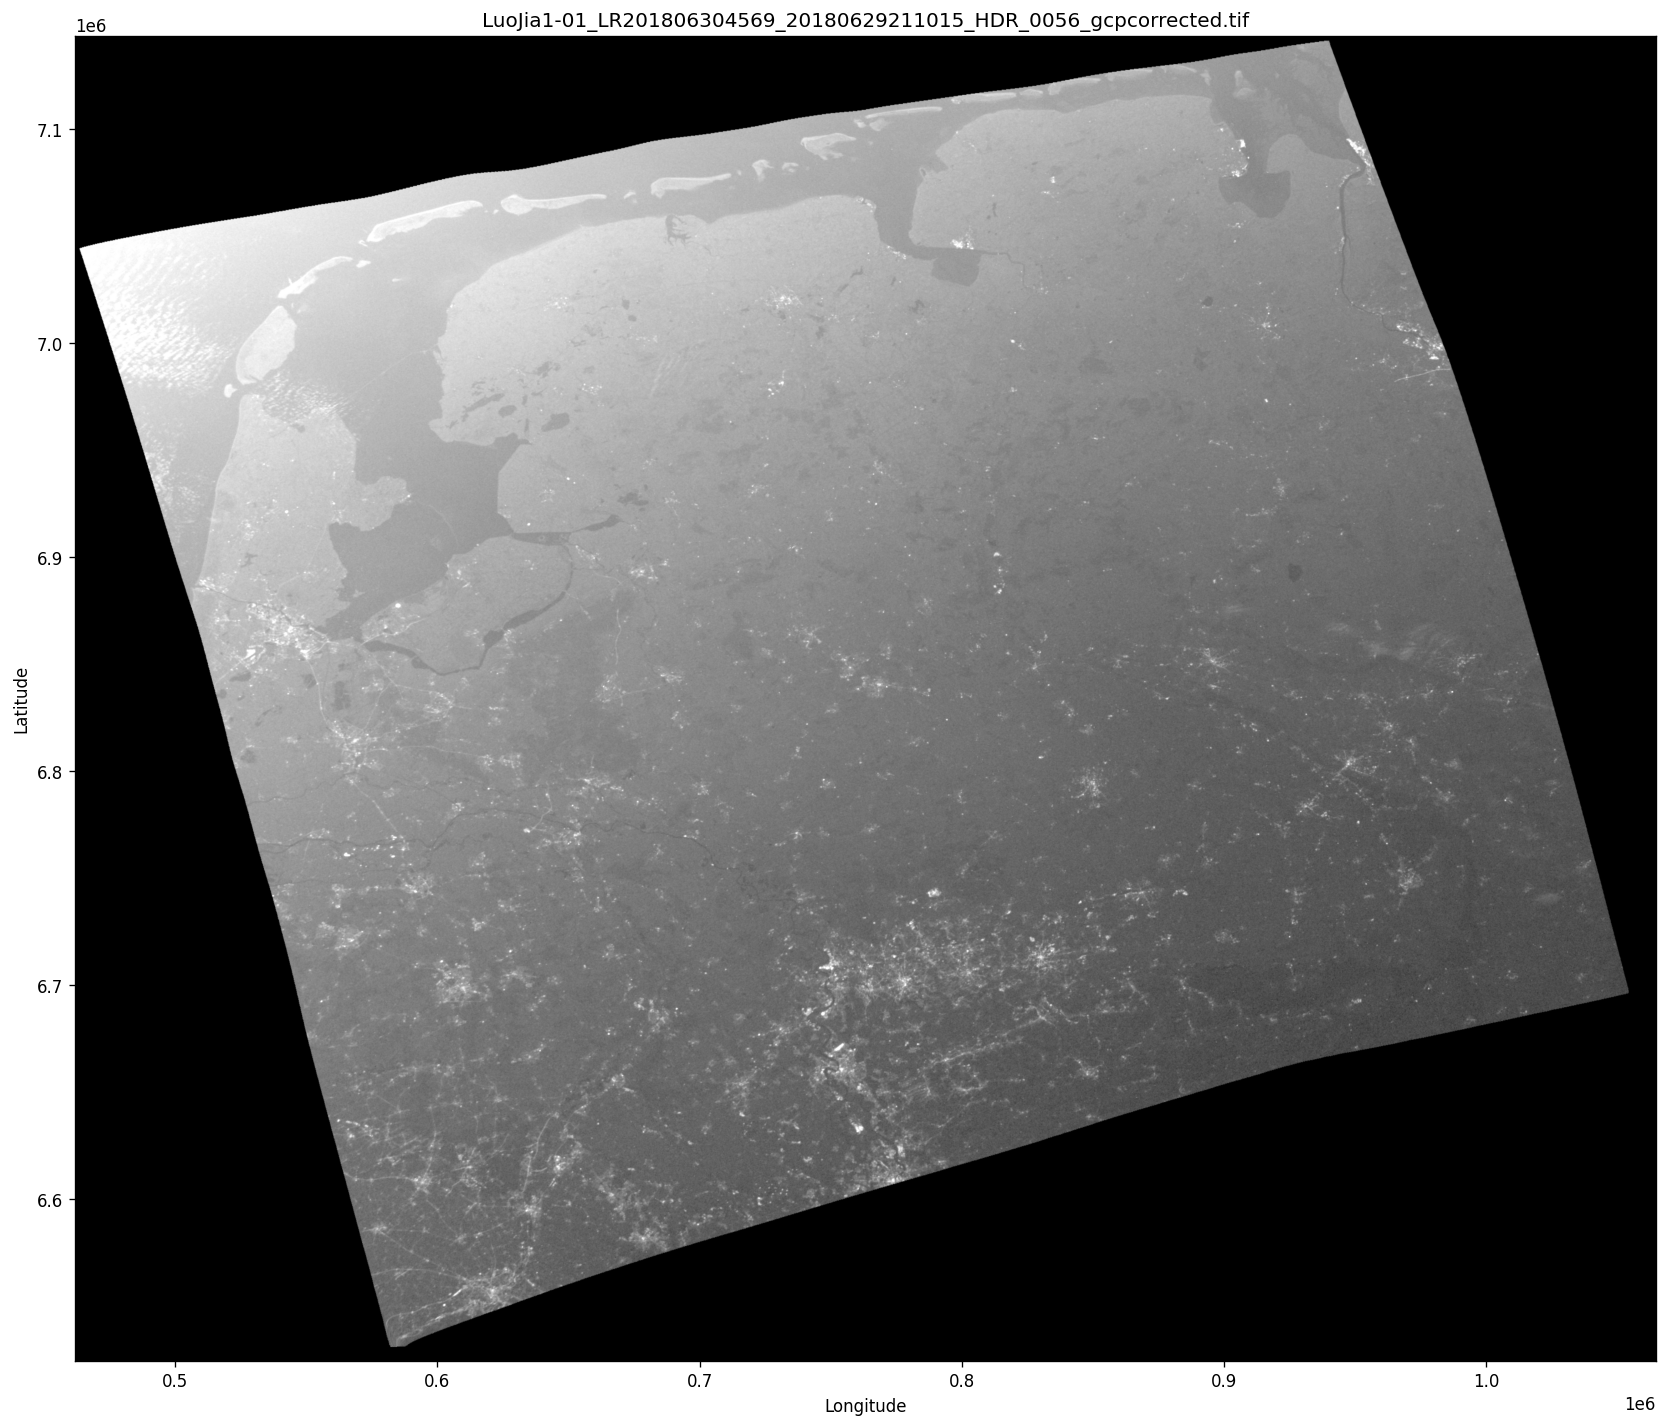

In [13]:

# =========================================================
# 7) Optional quick-look for one successful output
# =========================================================

if not success_df.empty:
    first_path = Path(success_df.iloc[0]["warped_path"])
    warped_arr, warped_gt, warped_proj_wkt, warped_w, warped_h, warped_nodata = read_single_band_array(first_path)
    warped_preview = robust_night_display(warped_arr)

    minx = warped_gt[0]
    maxy = warped_gt[3]
    maxx = minx + warped_w * warped_gt[1]
    miny = maxy + warped_h * warped_gt[5]

    fig_w = 14
    fig_h = max(5, min(12, fig_w * (warped_h / max(warped_w, 1))))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=120)
    ax.imshow(
        warped_preview,
        cmap="gray",
        extent=[minx, maxx, miny, maxy],
        origin="upper",
        aspect="auto",
    )
    ax.set_title(first_path.name)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.tight_layout()
    plt.show()
else:
    print("No successful warped outputs to preview yet.")


In [14]:
# Inspect metadata for every extracted TIFF
EXTRACTED_TIFF_DIR = LOCAL_SYNC_ROOT / "LUOJIA_EXTRACTED"

def _crs_label(proj_wkt):
    if not proj_wkt:
        return None
    try:
        return CRS.from_wkt(proj_wkt).to_string()
    except Exception:
        return proj_wkt[:120]

def _bounds_from_ds(ds):
    gt = ds.GetGeoTransform(can_return_null=True)
    if gt is None:
        return (None, None, None, None)

    w, h = ds.RasterXSize, ds.RasterYSize
    corners = [
        gdal.ApplyGeoTransform(gt, 0, 0),
        gdal.ApplyGeoTransform(gt, w, 0),
        gdal.ApplyGeoTransform(gt, 0, h),
        gdal.ApplyGeoTransform(gt, w, h),
    ]
    xs = [pt[0] for pt in corners]
    ys = [pt[1] for pt in corners]
    return min(xs), min(ys), max(xs), max(ys)

def show_tiff_metadata(file_name):
    tif_path = EXTRACTED_TIFF_DIR / file_name
    if not tif_path.exists():
        raise FileNotFoundError(tif_path)
    print(json.dumps(gdal.Info(str(tif_path), format="json"), indent=2, default=str))

tiff_paths = sorted(list(EXTRACTED_TIFF_DIR.glob("*.tif")) + list(EXTRACTED_TIFF_DIR.glob("*.tiff")))
if not tiff_paths:
    raise FileNotFoundError(f"No .tif/.tiff files found in {EXTRACTED_TIFF_DIR.resolve()}")

rows = []
for tif_path in tiff_paths:
    ds = open_gdal_dataset(tif_path)
    band1 = ds.GetRasterBand(1)
    min_x, min_y, max_x, max_y = _bounds_from_ds(ds)
    domains = [d for d in (ds.GetMetadataDomainList() or []) if d]

    rows.append({
        "file": tif_path.name,
        "width": ds.RasterXSize,
        "height": ds.RasterYSize,
        "bands": ds.RasterCount,
        "dtype_band1": gdal.GetDataTypeName(band1.DataType) if band1 else None,
        "nodata_band1": band1.GetNoDataValue() if band1 else None,
        "crs": _crs_label(ds.GetProjection()),
        "min_x": min_x,
        "min_y": min_y,
        "max_x": max_x,
        "max_y": max_y,
        "metadata_domains": ", ".join(domains) if domains else "default only",
    })
    ds = None

tiff_metadata_df = pd.DataFrame(rows).sort_values("file").reset_index(drop=True)
display(tiff_metadata_df)

sample = tiff_metadata_df.iloc[0]["file"]
print(f"Found {len(tiff_metadata_df)} TIFFs in {EXTRACTED_TIFF_DIR.resolve()}")
print(f"Run show_tiff_metadata('{sample}') to print the full GDAL metadata for one file.")


,file,width,height,bands,dtype_band1,nodata_band1,crs,min_x,min_y,max_x,max_y,metadata_domains
0,LuoJia1-01_LR201806057936_20180603171245_HDR_0...,2789,2307,1,UInt32,None,EPSG:4326,75.357703,27.265744,78.946589,30.234391,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
1,LuoJia1-01_LR201806057936_20180604191602_HDR_0...,2904,2315,1,UInt32,None,EPSG:4326,41.956751,33.745897,45.562357,36.620201,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
2,LuoJia1-01_LR201806064831_20180603055057_HDR_0...,2915,2347,1,UInt32,None,EPSG:4326,-118.692411,31.616914,-115.024758,34.569909,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
3,LuoJia1-01_LR201806143261_20180613193819_HDR_0...,3276,2277,1,UInt32,None,EPSG:4326,31.820021,42.539189,36.126323,45.532305,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
4,LuoJia1-01_LR201806145301_20180613144148_HDR_0...,3002,2208,1,UInt32,None,EPSG:4326,112.487126,29.779148,116.181087,32.496092,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
5,LuoJia1-01_LR201806145301_20180613144253_HDR_0...,3091,2177,1,UInt32,None,EPSG:4326,111.406785,33.730796,115.281662,36.459883,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
6,LuoJia1-01_LR201806145301_20180613144418_HDR_0...,3186,2090,1,UInt32,None,EPSG:4326,109.900639,38.881142,114.044988,41.599814,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
7,LuoJia1-01_LR201806158490_20180614132911_HDR_0...,3078,2219,1,UInt32,None,EPSG:4326,127.876707,33.458786,131.516442,36.082754,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
8,LuoJia1-01_LR201806175049_20180616141417_HDR_0...,2895,2253,1,UInt32,None,EPSG:4326,120.388814,24.062849,123.858472,26.763069,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"
9,LuoJia1-01_LR201806175049_20180616141503_HDR_0...,2941,2230,1,UInt32,None,EPSG:4326,119.710024,26.809410,123.273339,29.511278,"IMAGE_STRUCTURE, DERIVED_SUBDATASETS"


Found 34 TIFFs in C:\Users\cinoa\Desktop\NTL\Git Diffusion\diffusers\CREATEDATASET\local\LUOJIA_EXTRACTED
Run show_tiff_metadata('LuoJia1-01_LR201806057936_20180603171245_HDR_0030_gec.tif') to print the full GDAL metadata for one file.
